# Flu Vaccine Data Analyses

### Load Libraries 

In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(ggpubr)
  require(dplyr)
})


subject_color_map <- c(
  "FH1001" = "#1f77b4", "FH1002" = "#ff7f0e", "FH1003" = "#279e68",
  "FH1004" = "#d62728", "FH1005" = "#aa40fc", "FH1006" = "#8c564b",
  "FH1007" = "#e377c2", "FH1008" = "#b5bd61", "FH1009" = "#17becf",
  "FH1010" = "#aec7e8", "FH1011" = "#ffbb78", "FH1012" = "#98df8a",
  "FH1014" = "#ff9896", "FH1016" = "#c5b0d5", "FH1017" = "#c49c94",
  "FH1018" = "#f7b6d2", "FH1021" = "#dbdb8d"
)

In [2]:
### Load in Flu Data 
fluDat = fread('../../data/figure-inputs/msd/processed_flu_data.csv')

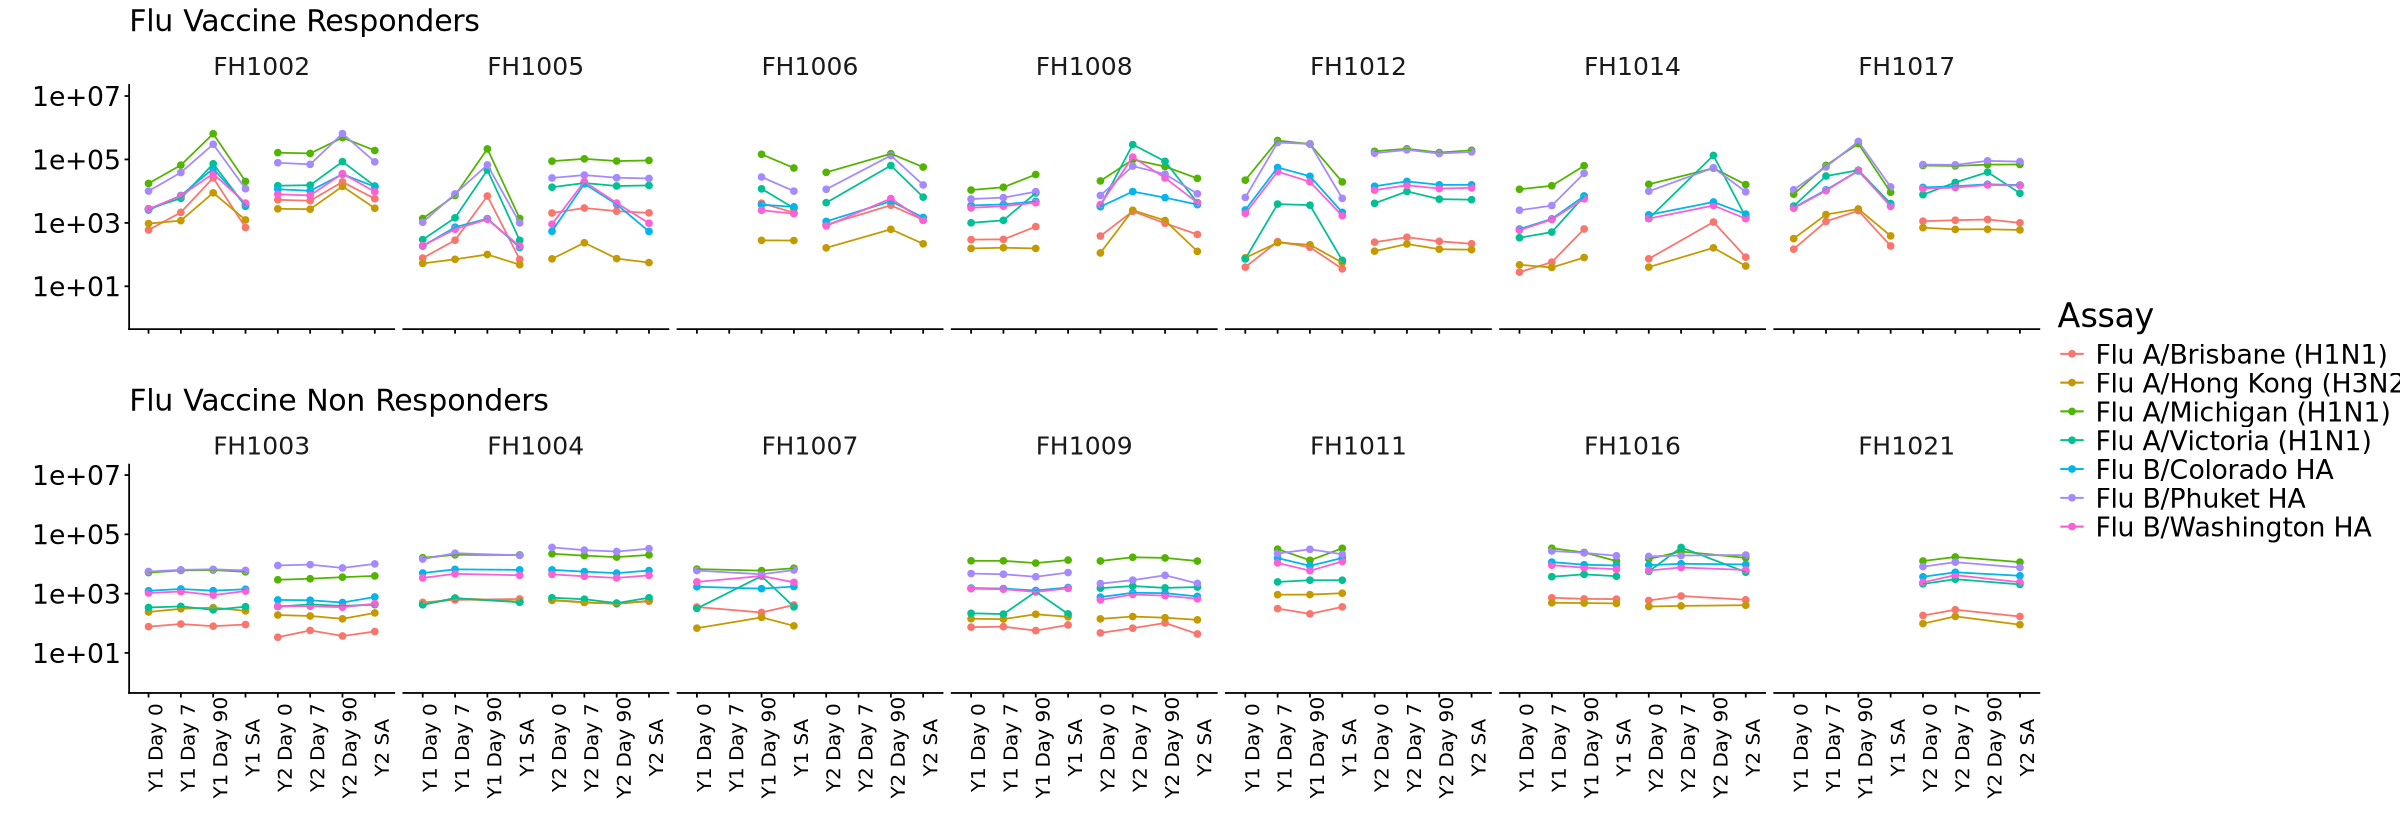

In [3]:
options(repr.plot.width = 20, repr.plot.height = 7)

ncol <- 7
textSize <- 20

## Plot line plots for vaccine responders
p1 <- ggplot(
  fluDat[fluDat$Responder == "Responder", ],
  aes(x = Visit, y = Value, col = Assay, group = Assay)
) +
  facet_wrap(~Subject, ncol = 7) +
  scale_y_log10(limits = c(1, 10e6)) +
  geom_point() +
  geom_line(
    data = fluDat[fluDat$Responder == "Responder" & Year == "Year 1", ],
    aes(x = Visit, y = Value, col = Assay, group = Assay)
  ) +
  geom_line(
    data = fluDat[fluDat$Responder == "Responder" & Year == "Year 2", ],
    aes(x = Visit, y = Value, col = Assay, group = Assay)
  ) +
  xlab("") +
  ylab("") +
  theme_classic() +
  theme(
    axis.text.x = element_blank(),
    strip.text.x = element_text(size = 15),
    strip.background = element_blank(),
    text = element_text(size = textSize), 
    plot.title = element_text(size = 18)
  ) +
  ggtitle("Flu Vaccine Responders")

## Plot line plots for vaccine non-responders
p2 <- ggplot(
  fluDat[fluDat$Responder == "Non-Responder", ],
  aes(x = Visit, y = Value, col = Assay, group = Assay)
) +
  facet_wrap(~Subject, ncol = 7) +
  scale_y_log10(limits = c(1, 10e6)) +
  geom_point() +
  geom_line(
    data = fluDat[fluDat$Responder == "Non-Responder" & Year == "Year 1", ],
    aes(x = Visit, y = Value, col = Assay, group = Assay)
  ) +
  geom_line(
    data = fluDat[fluDat$Responder == "Non-Responder" & Year == "Year 2", ],
    aes(x = Visit, y = Value, col = Assay, group = Assay)
  ) +
  xlab("") +
  ylab("") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 90, size = 12),
    strip.text.x = element_text(size = 15),
    strip.background = element_blank(),
    text = element_text(size = textSize), 
    plot.title = element_text(size = 18)
  ) +
  ggtitle("Flu Vaccine Non Responders")

p <- ggpubr::ggarrange(p1, p2, ncol = 1, heights = c(1.65, 2), common.legend = TRUE, legend = "right")
p
ggsave("../../data/figure-outputs/figure-7/fig_7b.pdf", plot = p, width = 20, height = 7, dpi = 200, device = cairo_pdf)